# Business Scenario

A real estate analytics company helps customers estimate the market value of residential properties.

Property prices do not always increase smoothly:
- Prices jump based on location
- Amenities create sudden price differences
- Market behaviour is noisy and inconsistent

The company wants a reliable pricing system that can:
- Handle non-linear relationships
- Work well with noisy real-world data
- Provide stable predictions for unseen properties


You are hired as a Data Analyst to build this pricing solution.
1. Load the dataset and examine the available property attributes.
2. Identify input features that may influence house prices (e.g., size, bedrooms, bathrooms, location-related fields).
3. Build a regression model that predicts house price based on the selected features.
4. Train the model using historical property data.Predict prices for unseen property records.
5. Evaluate the model performance using:
    - Mean Squared Error (MSE)
    - R² score

6. Analyze the prediction behavior
7. Build an alternative regression model that combines predictions from multiple rule-based models.
8. Compare the two models based on:
    - Does the model produce smooth or step-wise predictions?
    - Does it react strongly to small changes in input?
    - Stability of predictions
    - Sensitivity to noise
    - Performance on test data

In [1]:
# 1. Load the Dataset
import numpy as np
import pandas as pd

rf = pd.read_csv(r"house_data.csv")

In [2]:
rf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [3]:
rf.shape

(4600, 18)

In [4]:
rf.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [5]:
rf.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [6]:
rf.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [7]:
rf.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

### 2. Feature selection

In [ ]:
# 2. Identify input features that may influence house prices (e.g., size, bedrooms, bathrooms, location-related fields).

    
X = rf.drop(columns = ['date', 'price', 'city', 'country', 'statezip', 'street']).values  
y = rf['price'].values  # Target variable: house price


### 3. Train–test split

In [9]:
# 3. Build a regression model that predicts house price based on the selected features.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




### 4. Model training

#### Random Forest

In [10]:
# 4. Train the model using historical property data.Predict prices for unseen property records.

# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)




,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(X_test)

#### Decision Tree

In [12]:
# Decision Tree Regression 
from sklearn.tree import DecisionTreeRegressor

model1 = DecisionTreeRegressor(random_state=42)
model1.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [13]:
y_pred1 = model1.predict(X_test)

### 5. Evaluation

In [17]:
# 5. Evaluate the model performance using:
# Mean Squared Error (MSE)
# R² score

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RandomForestRegressor Results:")
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


RandomForestRegressor Results:
Mean Squared Error: 991775851992.8134
R² Score: 0.027524232809177818


In [19]:
# 5. Evaluate the model performance using:
# Mean Squared Error (MSE)
# R² score
# Decision Tree Regression

from sklearn.metrics import mean_squared_error, r2_score
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)
print("Decision Tree Results:")
print(f"Mean Squared Error: {mse1}")
print(f"R² Score: {r2_1}")

Decision Tree Results:
Mean Squared Error: 1052121827350.4335
R² Score: -0.03164740215739448


### 6. Analysis of Prediction Behavior

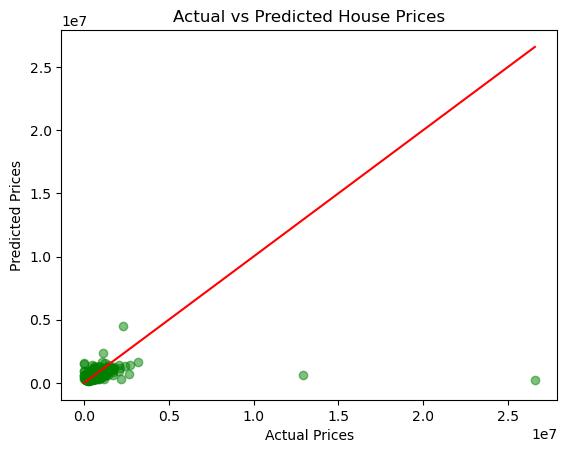

In [18]:
# 6. Analyze the prediction behavior

# Visualize Actual vs Predicted Prices
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5, color = 'green')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line
plt.show()


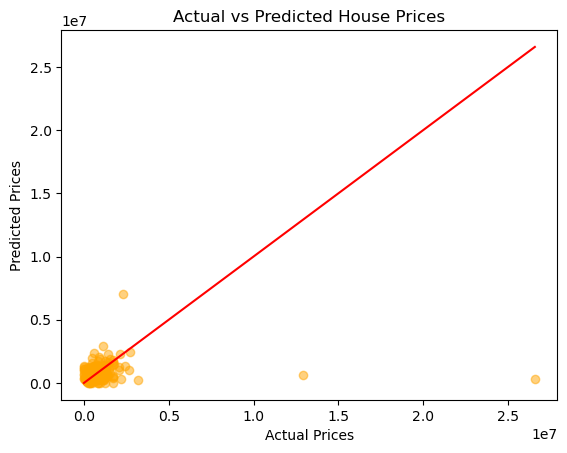

In [20]:
# Decision Tree Regression

# Visualize Actual vs Predicted Prices
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred1, alpha=0.5, color = 'Orange')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line
plt.show()


### 7. Combined Regression Model Using Rule-Based Learners

In [21]:
# 7. Build an alternative regression model that combines predictions from multiple rule-based models.   

from sklearn.ensemble import VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# Individual rule-based models
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
et = ExtraTreesRegressor(n_estimators=100, random_state=42)

# Ensemble model (Voting Regressor)
ensemble_model = VotingRegressor(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('et', et)
    ]
)

# Train ensemble
ensemble_model.fit(X_train, y_train)

# Predict
y_pred_ensemble = ensemble_model.predict(X_test)


In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_ensemble = mean_squared_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)

print("Ensemble Model Results:")
print("Mean Squared Error:", mse_ensemble)
print("RMSE:", np.sqrt(mse_ensemble))
print("R² Score:", r2_ensemble)


Ensemble Model Results:
Mean Squared Error: 989155123074.8573
RMSE: 994562.7798559814
R² Score: 0.030093962007531894


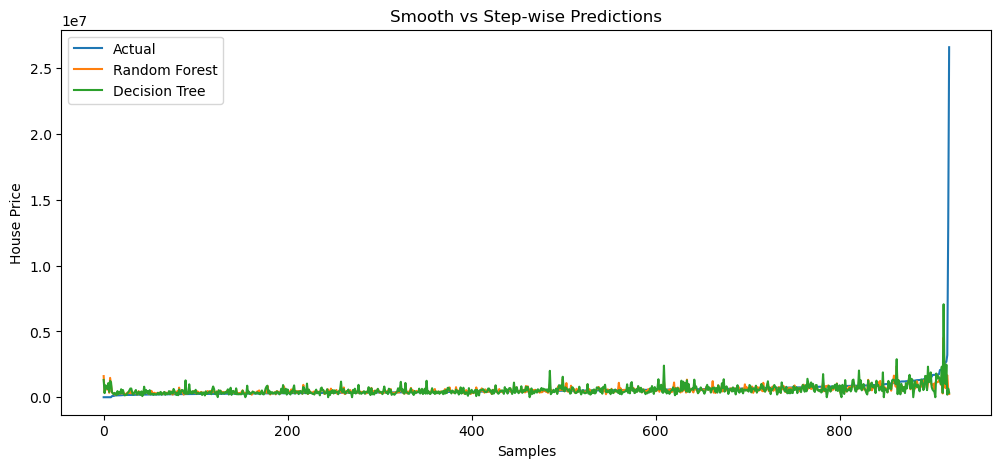

In [33]:
# 8. Compare the two models based on:

# -1- Does the model produce smooth or step-wise predictions?
import matplotlib.pyplot as plt
import numpy as np

# Sort for smooth plotting
idx = np.argsort(y_test)

plt.figure(figsize=(12,5))

plt.plot(y_test[idx], label="Actual")
plt.plot(y_pred[idx], label="Random Forest")
plt.plot(y_pred1[idx], label="Decision Tree")

plt.xlabel("Samples")
plt.ylabel("House Price")
plt.title("Smooth vs Step-wise Predictions")
plt.legend()
plt.show()

   
   
   

In [34]:
# -2- Does it react strongly to small changes in input?
X_test_perturbed = X_test.copy()
X_test_perturbed[:, 0] += 1  # small change in first feature

rf_change = np.mean(np.abs(model.predict(X_test_perturbed) - y_pred))
dt_change = np.mean(np.abs(model1.predict(X_test_perturbed) - y_pred1))

print("Random Forest sensitivity:", rf_change)
print("Decision Tree sensitivity:", dt_change)

Random Forest sensitivity: 56028.60058746176
Decision Tree sensitivity: 194087.91572565978


In [32]:
# -3- Stability of predictions
from sklearn.utils import resample

rf_preds = []
dt_preds = []

for i in range(10):
    X_s, y_s = resample(X_train, y_train, random_state=i)
    
    model.fit(X_s, y_s)
    model1.fit(X_s, y_s)
    
    rf_preds.append(model.predict(X_test))
    dt_preds.append(model1.predict(X_test))

rf_variance = np.var(rf_preds)
dt_variance = np.var(dt_preds)

print("Random Forest prediction variance:", rf_variance)
print("Decision Tree prediction variance:", dt_variance)


Random Forest prediction variance: 79505239890.84589
Decision Tree prediction variance: 148032102227.14673


In [31]:
# -4- Sensitivity to noise
noise = np.random.normal(0, 0.01, X_test.shape)
X_noisy = X_test + noise

rf_noise_error = np.mean(np.abs(model.predict(X_noisy) - y_pred))
dt_noise_error = np.mean(np.abs(model1.predict(X_noisy) - y_pred1))

print("Random Forest noise sensitivity:", rf_noise_error)
print("Decision Tree noise sensitivity:", dt_noise_error)


Random Forest noise sensitivity: 50437.28364370749
Decision Tree noise sensitivity: 185962.9669732362


In [30]:
# -5- Performance on test data
from sklearn.metrics import mean_squared_error, r2_score

print("Random Forest Performance")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

print("\nDecision Tree Performance")
print("MSE:", mean_squared_error(y_test, y_pred1))
print("R²:", r2_score(y_test, y_pred1))


Random Forest Performance
MSE: 991775851992.8134
R²: 0.027524232809177818

Decision Tree Performance
MSE: 1052121827350.4335
R²: -0.03164740215739448
